In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/PJM_Load_hourly.csv")

df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.sort_values("Datetime")

df = df.set_index("Datetime")

df.head()

,PJM_Load_MW
Datetime,
1998-04-01 01:00:00,22259.0
1998-04-01 02:00:00,21244.0
1998-04-01 03:00:00,20651.0
1998-04-01 04:00:00,20421.0
1998-04-01 05:00:00,20713.0


In [3]:
df["time_idx"] = np.arange(len(df))

df[["PJM_Load_MW", "time_idx"]].head()

,PJM_Load_MW,time_idx
Datetime,,
1998-04-01 01:00:00,22259.0,0
1998-04-01 02:00:00,21244.0,1
1998-04-01 03:00:00,20651.0,2
1998-04-01 04:00:00,20421.0,3
1998-04-01 05:00:00,20713.0,4


In [4]:
X_trend = df[["time_idx"]]

y_trend = df["PJM_Load_MW"]

trend_model = LinearRegression()

trend_model.fit(X_trend, y_trend)

df["trend_prediction"] = trend_model.predict(X_trend)

df.head()

,PJM_Load_MW,time_idx,trend_prediction
Datetime,,,
1998-04-01 01:00:00,22259.0,0,28926.935424
1998-04-01 02:00:00,21244.0,1,28926.986464
1998-04-01 03:00:00,20651.0,2,28927.037505
1998-04-01 04:00:00,20421.0,3,28927.088546
1998-04-01 05:00:00,20713.0,4,28927.139586


In [5]:
df["residual"] = (
    df["PJM_Load_MW"]
    - df["trend_prediction"]
)

df[["PJM_Load_MW",
    "trend_prediction",
    "residual"]].head()

,PJM_Load_MW,trend_prediction,residual
Datetime,,,
1998-04-01 01:00:00,22259.0,28926.935424,-6667.935424
1998-04-01 02:00:00,21244.0,28926.986464,-7682.986464
1998-04-01 03:00:00,20651.0,28927.037505,-8276.037505
1998-04-01 04:00:00,20421.0,28927.088546,-8506.088546
1998-04-01 05:00:00,20713.0,28927.139586,-8214.139586


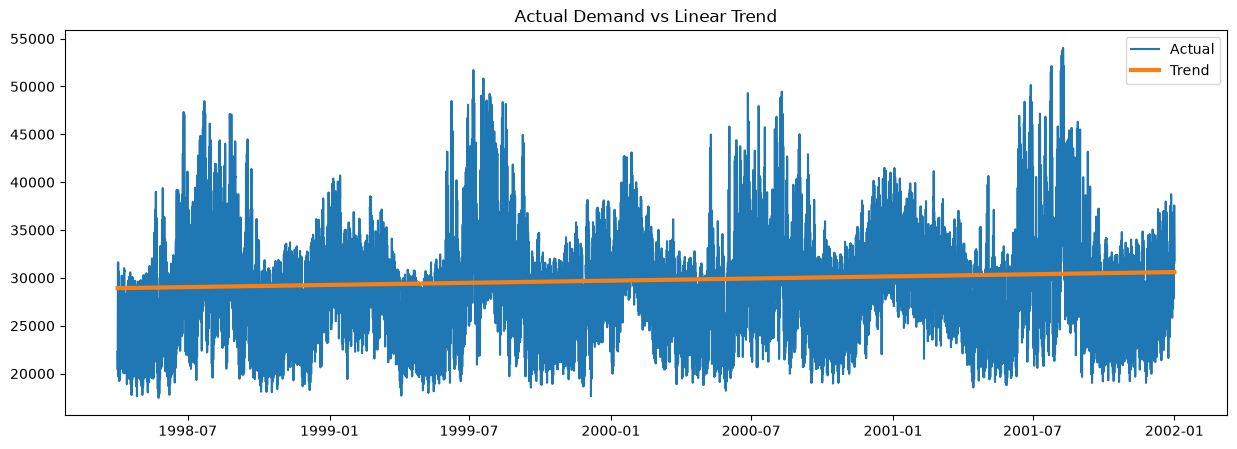

In [6]:
plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["PJM_Load_MW"],
    label="Actual"
)

plt.plot(
    df.index,
    df["trend_prediction"],
    label="Trend",
    linewidth=3
)

plt.legend()

plt.title("Actual Demand vs Linear Trend")

plt.show()

In [7]:
df[["PJM_Load_MW","trend_prediction","residual"]].head()

,PJM_Load_MW,trend_prediction,residual
Datetime,,,
1998-04-01 01:00:00,22259.0,28926.935424,-6667.935424
1998-04-01 02:00:00,21244.0,28926.986464,-7682.986464
1998-04-01 03:00:00,20651.0,28927.037505,-8276.037505
1998-04-01 04:00:00,20421.0,28927.088546,-8506.088546
1998-04-01 05:00:00,20713.0,28927.139586,-8214.139586


In [8]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["year"] = df.index.year

In [9]:
df[["hour","dayofweek","month","year"]].head()

,hour,dayofweek,month,year
Datetime,,,,
1998-04-01 01:00:00,1,2,4,1998
1998-04-01 02:00:00,2,2,4,1998
1998-04-01 03:00:00,3,2,4,1998
1998-04-01 04:00:00,4,2,4,1998
1998-04-01 05:00:00,5,2,4,1998


In [10]:
df.columns

Index(['PJM_Load_MW', 'time_idx', 'trend_prediction', 'residual', 'hour',
       'dayofweek', 'month', 'year'],
      dtype='str')

In [11]:
# Lag Features

for lag in range(1, 25):
    df[f"lag_{lag}"] = df["PJM_Load_MW"].shift(lag)

# Rolling Features

df["rolling_mean_24"] = df["PJM_Load_MW"].rolling(24).mean()

df["rolling_std_24"] = df["PJM_Load_MW"].rolling(24).std()

df["rolling_min_24"] = df["PJM_Load_MW"].rolling(24).min()

df["rolling_max_24"] = df["PJM_Load_MW"].rolling(24).max()

# Remove boundary NaNs

df = df.dropna()

print(df.shape)

(32872, 36)


In [12]:
df["residual"].describe()

count    32872.000000
mean         0.952377
std       5830.571682
min     -12050.020201
25%      -4294.320555
50%        -64.838467
75%       3248.393926
max      23600.885608
Name: residual, dtype: float64

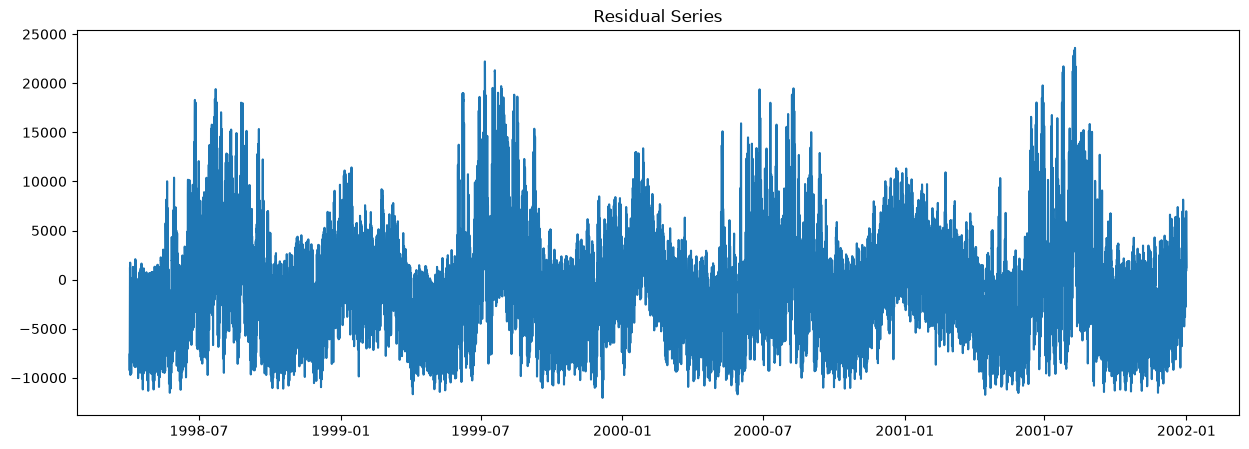

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df.index, df["residual"])
plt.title("Residual Series")
plt.show()

In [14]:
feature_cols = [
    "hour",
    "dayofweek",
    "month",
    "year"
]

feature_cols += [f"lag_{i}" for i in range(1, 25)]

feature_cols += [
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_min_24",
    "rolling_max_24"
]

X = df[feature_cols]
y = df["residual"]

print(X.shape)
print(y.shape)

(32872, 32)
(32872,)


In [15]:
from lightgbm import LGBMRegressor

OSError: dlopen(/Users/kumarsanu/DemandSense-AI/venv/lib/python3.14/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Users/kumarsanu/DemandSense-AI/venv/lib/python3.14/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file)

In [16]:
from lightgbm import LGBMRegressor

print("LightGBM Loaded Successfully")

LightGBM Loaded Successfully


In [17]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

In [18]:
from sklearn.model_selection import train_test_split

train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(26297, 32)
(6575, 32)


In [19]:
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000397 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7189
[LightGBM] [Info] Number of data points in the train set: 26297, number of used features: 32
[LightGBM] [Info] Start training from score 111.114939
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,max_depth,8
,learning_rate,0.05
,n_estimators,500
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [20]:
residual_pred = model.predict(X_test)

print(residual_pred[:5])

[-5833.25943547 -6910.73712416 -7384.30168512 -7314.31523888
 -6461.5300692 ]


In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, residual_pred)
r2 = r2_score(y_test, residual_pred)

print("Residual MAE:", round(mae, 2))
print("Residual R²:", round(r2, 4))

Residual MAE: 471.05
Residual R²: 0.991


In [22]:
trend_test = df.loc[X_test.index, "trend_prediction"]

In [23]:
final_prediction = trend_test + residual_pred

In [24]:
actual_demand = df.loc[X_test.index, "PJM_Load_MW"]

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(actual_demand, final_prediction)

rmse = np.sqrt(
    np.mean(
        (actual_demand - final_prediction) ** 2
    )
)

r2 = r2_score(
    actual_demand,
    final_prediction
)

print("Hybrid MAE :", round(mae,2))
print("Hybrid RMSE:", round(rmse,2))
print("Hybrid R²  :", round(r2,4))

Hybrid MAE : 471.05
Hybrid RMSE: 605.61
Hybrid R²  : 0.991


In [26]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    actual_demand,
    final_prediction
)

print("MAPE:", round(mape * 100, 2), "%")

MAPE: 1.61 %


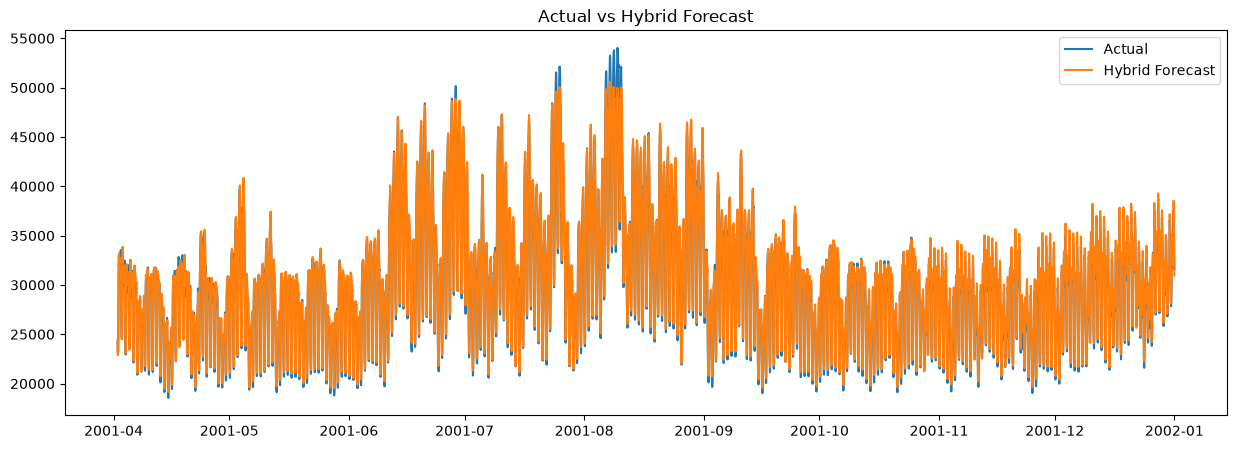

In [27]:
plt.figure(figsize=(15,5))

plt.plot(
    actual_demand.index,
    actual_demand,
    label="Actual"
)

plt.plot(
    actual_demand.index,
    final_prediction,
    label="Hybrid Forecast"
)

plt.legend()

plt.title("Actual vs Hybrid Forecast")

plt.show()

In [28]:
comparison = pd.DataFrame({
    "Actual": actual_demand,
    "Predicted": final_prediction
})

comparison.head()

,Actual,Predicted
Datetime,,
2001-04-02 01:00:00,24228.0,24437.118366
2001-04-02 02:00:00,23277.0,23359.691718
2001-04-02 03:00:00,22933.0,22886.178198
2001-04-02 04:00:00,22919.0,22956.215685
2001-04-02 05:00:00,23480.0,23809.051895


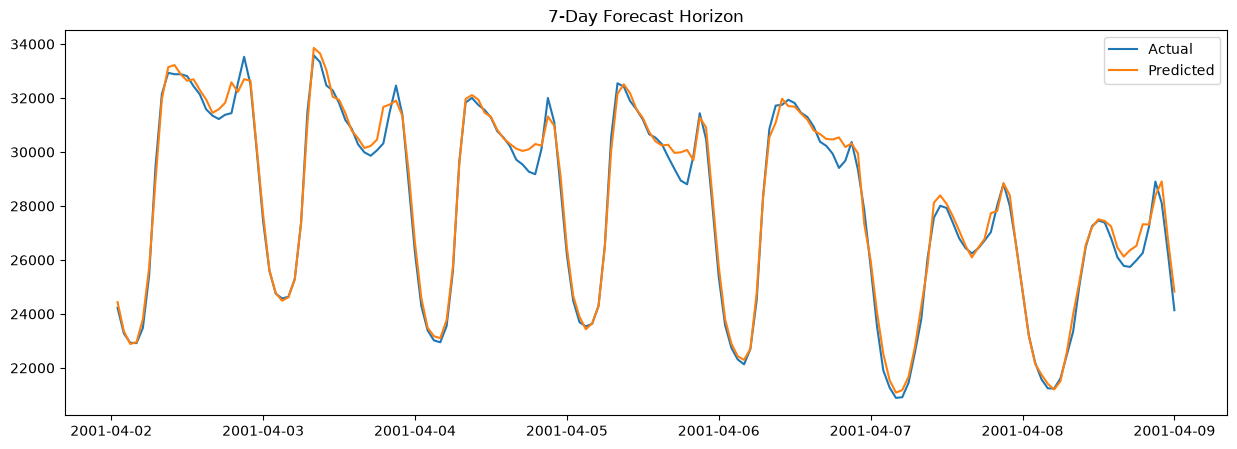

In [29]:
comparison_7days = comparison.iloc[:24*7]

plt.figure(figsize=(15,5))

plt.plot(
    comparison_7days.index,
    comparison_7days["Actual"],
    label="Actual"
)

plt.plot(
    comparison_7days.index,
    comparison_7days["Predicted"],
    label="Predicted"
)

plt.legend()

plt.title("7-Day Forecast Horizon")

plt.show()

In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,hour,1982
4,lag_1,1975
2,month,825
27,lag_24,762
1,dayofweek,752
31,rolling_max_24,652
5,lag_2,650
29,rolling_std_24,570
30,rolling_min_24,463
3,year,462


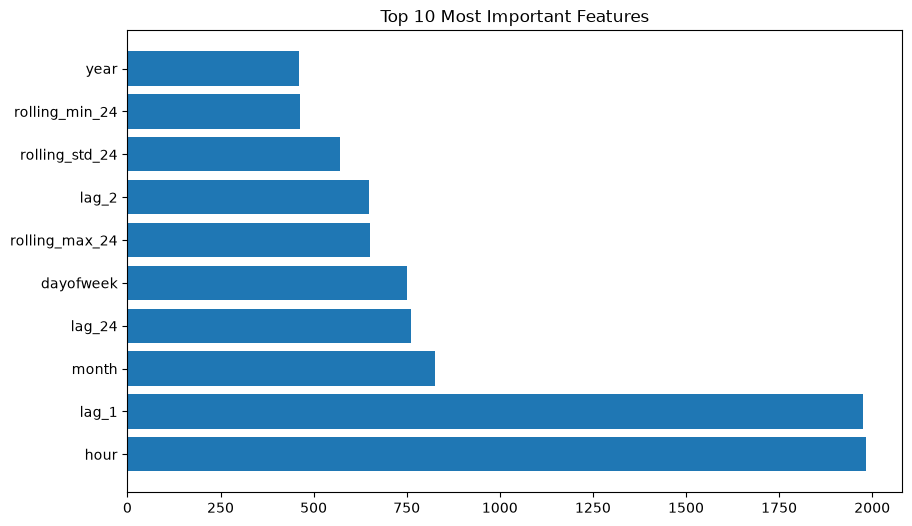

In [31]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Most Important Features")

plt.show()

In [32]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np
import pandas as pd

In [33]:
results = []

tscv = TimeSeriesSplit(n_splits=5)

In [34]:
for fold, (train_idx, test_idx) in enumerate(tscv.split(df), start=1):

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Features
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]

    # Residual target
    y_train = train_df["residual"]
    y_test = test_df["residual"]

    # LightGBM
    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    )

    model.fit(X_train, y_train)

    residual_pred = model.predict(X_test)

    trend_test = test_df["trend_prediction"]

    final_pred = trend_test + residual_pred

    actual = test_df["PJM_Load_MW"]

    mae = mean_absolute_error(actual, final_pred)

    rmse = np.sqrt(
        np.mean((actual - final_pred) ** 2)
    )

    mape = mean_absolute_percentage_error(
        actual,
        final_pred
    ) * 100

    results.append([
        fold,
        mae,
        rmse,
        mape
    ])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000324 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7160
[LightGBM] [Info] Number of data points in the train set: 5482, number of used features: 31
[LightGBM] [Info] Start training from score -134.118990
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [35]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Fold",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

results_df

,Fold,MAE,RMSE,MAPE
0,1,544.898754,718.667296,1.883664
1,2,437.238176,594.687660,1.409753
2,3,393.901245,506.572737,1.331378
3,4,425.905756,530.788687,1.434450
4,5,389.627411,553.454159,1.254701


In [36]:
results_df.mean(numeric_only=True)

Fold      3.000000
MAE     438.314268
RMSE    580.834108
MAPE      1.462789
dtype: float64

In [37]:
results_df

,Fold,MAE,RMSE,MAPE
0,1,544.898754,718.667296,1.883664
1,2,437.238176,594.687660,1.409753
2,3,393.901245,506.572737,1.331378
3,4,425.905756,530.788687,1.434450
4,5,389.627411,553.454159,1.254701


In [38]:
results_df.mean(numeric_only=True)

Fold      3.000000
MAE     438.314268
RMSE    580.834108
MAPE      1.462789
dtype: float64

In [39]:
print(type(y_test_actual))
print(type(hybrid_pred))

NameError: name 'y_test_actual' is not defined

In [40]:
y_test

Datetime
2001-05-17 18:00:00    -491.369454
2001-05-17 19:00:00    -834.420495
2001-05-17 20:00:00    -792.471535
2001-05-17 21:00:00     -42.522576
2001-05-17 22:00:00    -877.573617
                          ...     
2001-12-31 20:00:00    5786.284771
2001-12-31 21:00:00    4476.233731
2001-12-31 22:00:00    3284.182690
2001-12-31 23:00:00    1984.131649
2002-01-01 00:00:00     963.080608
Name: residual, Length: 5478, dtype: float64

In [41]:
print(type(y_test))
print(type(hybrid_pred))

<class 'pandas.Series'>


NameError: name 'hybrid_pred' is not defined

In [46]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "RF + Lag Features",
        "Hybrid Model"
    ],
    "R2": [
        0.7167,
        0.9159,
        0.9910
    ]
})

comparison.to_csv(
    "model_comparison.csv",
    index=False
)